# Vector portal — Letter figures

Reproduces the figures of the companion Letter for the `VectorPortal` model. Section 1 is a pure post-processing of the precomputed scans in `output/vP/`; Sections 2 and 3 run the Boltzmann / rate code live on a single benchmark.

- **Section 1 — bounds plot in $(m_X, \varepsilon)$.** Two panels for $m_X/m_{Z^\prime} = 2.5$ and $5.0$, each overlaying $\alpha_X = 10^{-3}$ and $10^{-2}$. Shown: relic-abundance line (joint + secluded stages), BBN hadronic-injection upper bound, direct-detection exclusions (LZ + XENONnT envelope), Xe neutrino fog, and the thermalisation-floor heuristic. The twin lower-axis pair plots $\langle\sigma v\rangle_X$ on the relic line against the WIMP value $4\times 10^{-26}\,{\rm cm^3/s}$. Driven from `output/vP/relic_joint_aX*_r*.dat`.
- **Section 2 — energy / entropy / temperature evolution.** Single benchmark ($m_X = 100$ GeV, $m_{Z^\prime} = 40$ GeV, $\alpha_X = 10^{-3}$). Solves the three-phase Boltzmann system, fixes $\varepsilon$ from the relic constraint, then runs the background evolution and plots $\rho_i/\rho_{\rm tot}$, $S/S_i$, and $\xi = T_h/T_{\rm SM}$ vs $T$. Illustrates the late entropy injection from $Z^\prime \to f\bar f$.
- **Section 3 — $\Gamma/H$ vs $T$.** Same benchmark plus a heavy-mediator scattering channel ($M = 10^{12}$ GeV). Compares three rates against Hubble: high-scale $f\,(X,Z^\prime) \leftrightarrow f\,(X,Z^\prime)$ ($T^5/M^4$ at low $T$, $T$ at high $T$), $Z^\prime$ decay / inverse-decay, and Compton-like $f\,Z^\prime \leftrightarrow \gamma\,f$. Motivates the secluded-regime assumption that the hidden sector is *never* in equilibrium with the SM at temperatures relevant for freeze-out.

A trailing cell plots the phase-space factors $\Delta_2(r)$ and $\Delta_3(r)$ that enter the $3\to2$ cannibal cross sections.

Outputs are written to `letter_figs/`

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
import matplotlib.colors as mcolors
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from hidden_sector_DM.HiddenSectorDM import Cosmology, VectorPortal, BoltzmannSolver

plt.style.use('mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

## 1. Figure 1 of the Letter

In [4]:
def load_relic(fname):
    # Column names (7 entries)
    keys = [
        "mXs", "mYs", "epsXs", "epsXs_bbn",
        "Och2", "GoH_handoff", "regime"
    ]
    # Load data (skip commented lines)
    data = np.loadtxt(fname, comments="#")
    # Convert to dictionary
    return {k: data[:, i] for i, k in enumerate(keys)}

In [5]:
HBARC_GEV_CM = 1.9732698044e-14        # GeV·cm
C_CM_S       = 2.99792458e10           # cm/s (exact)
GEVm2_TO_CM3_S = HBARC_GEV_CM**2 * C_CM_S 

def sigmav_XX_to_YY_swave(mX: float, mY: float, alphaX: float) -> float:
    """<sigma v> for X Xbar -> Y Y  (s-wave, finite mY)."""
    rv = mY / mX
    return (4.0 * np.pi * alphaX**2 / mX**2
            * (1.0 - rv**2)**1.5 / (2.0 - rv**2)**2)*GEVm2_TO_CM3_S
aXs_rs_str=['aX1e-03_r2.5','aX1e-03_r5.0','aX1e-02_r2.5','aX1e-02_r5.0']
aXs_rs_vals=np.array([[1e-3,2.5],[1e-3,5],[1e-2,2.5],[1e-2,5]])
aXs_rs_tex=np.array([[r'$10^{-3}$','2.5'],[r'$10^{-3}$','5'],
                     [r'$10^{-2}$','2.5'],[r'$10^{-2}$','5']])
dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
therm_floors=[]
for i in trange(len(aXs_rs_str)):
    dat1 = load_relic("../output/vP/relic_joint_"+str(aXs_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1, regime_bools = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn'], dat1['regime']
    svs1=np.array([sigmav_XX_to_YY_swave(mXs1[k],mXs1[k]/aXs_rs_vals[i][1],aXs_rs_vals[i][0]) for k in range(len(mXs1))])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    mask = ~np.isnan(epsXs_bbn1)
    idx_th=np.argmax(mask)-1
    mX_therm,eps_therm= mXs1[idx_th],epsXs1[idx_th]
    therm_floors.append([mX_therm, eps_therm])
    i0 = np.argmin(mXs1[mask])
    mXs_bbn_interp, epsXs_bbn_interp = mXs1[mask][i0:], epsXs_bbn1[mask][i0:]
    bbn_bound=interp1d(np.log10(mXs_bbn_interp), np.log10(epsXs_bbn_interp), kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=10**bbn_bound(np.log10(mXs_bbn_dd))
    epsXs_LZ=np.ones(len(mXs_bbn_dd))
    epsXs_Xe=np.ones(len(mXs_bbn_dd))
    epsXs_nu=np.ones(len(mXs_bbn_dd))
    for j in range(len(mXs_bbn_dd)):
        model = VectorPortal(
          mX=mXs_bbn_dd[j],
          mY=mXs_bbn_dd[j]/aXs_rs_vals[i][1],
          alphaX=aXs_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_Xe[j]= solver.find_epsilon_DD(constraint='XENONnT',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))    
        except:
            continue
    epsXs_LZ[np.isnan(epsXs_LZ)] = 1
    epsXs_Xe[np.isnan(epsXs_Xe)] = 1
    epsXs_nu[epsXs_nu==1] = np.nan
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,
          'epsXs_LZ':epsXs_LZ,'epsXs_XenT':epsXs_Xe,'epsXs_nu':epsXs_nu, 'svXs':svs1}
    dats.append(Dict)
    del Dict
therm_floors=np.array(therm_floors)

 ... (more hidden) ...


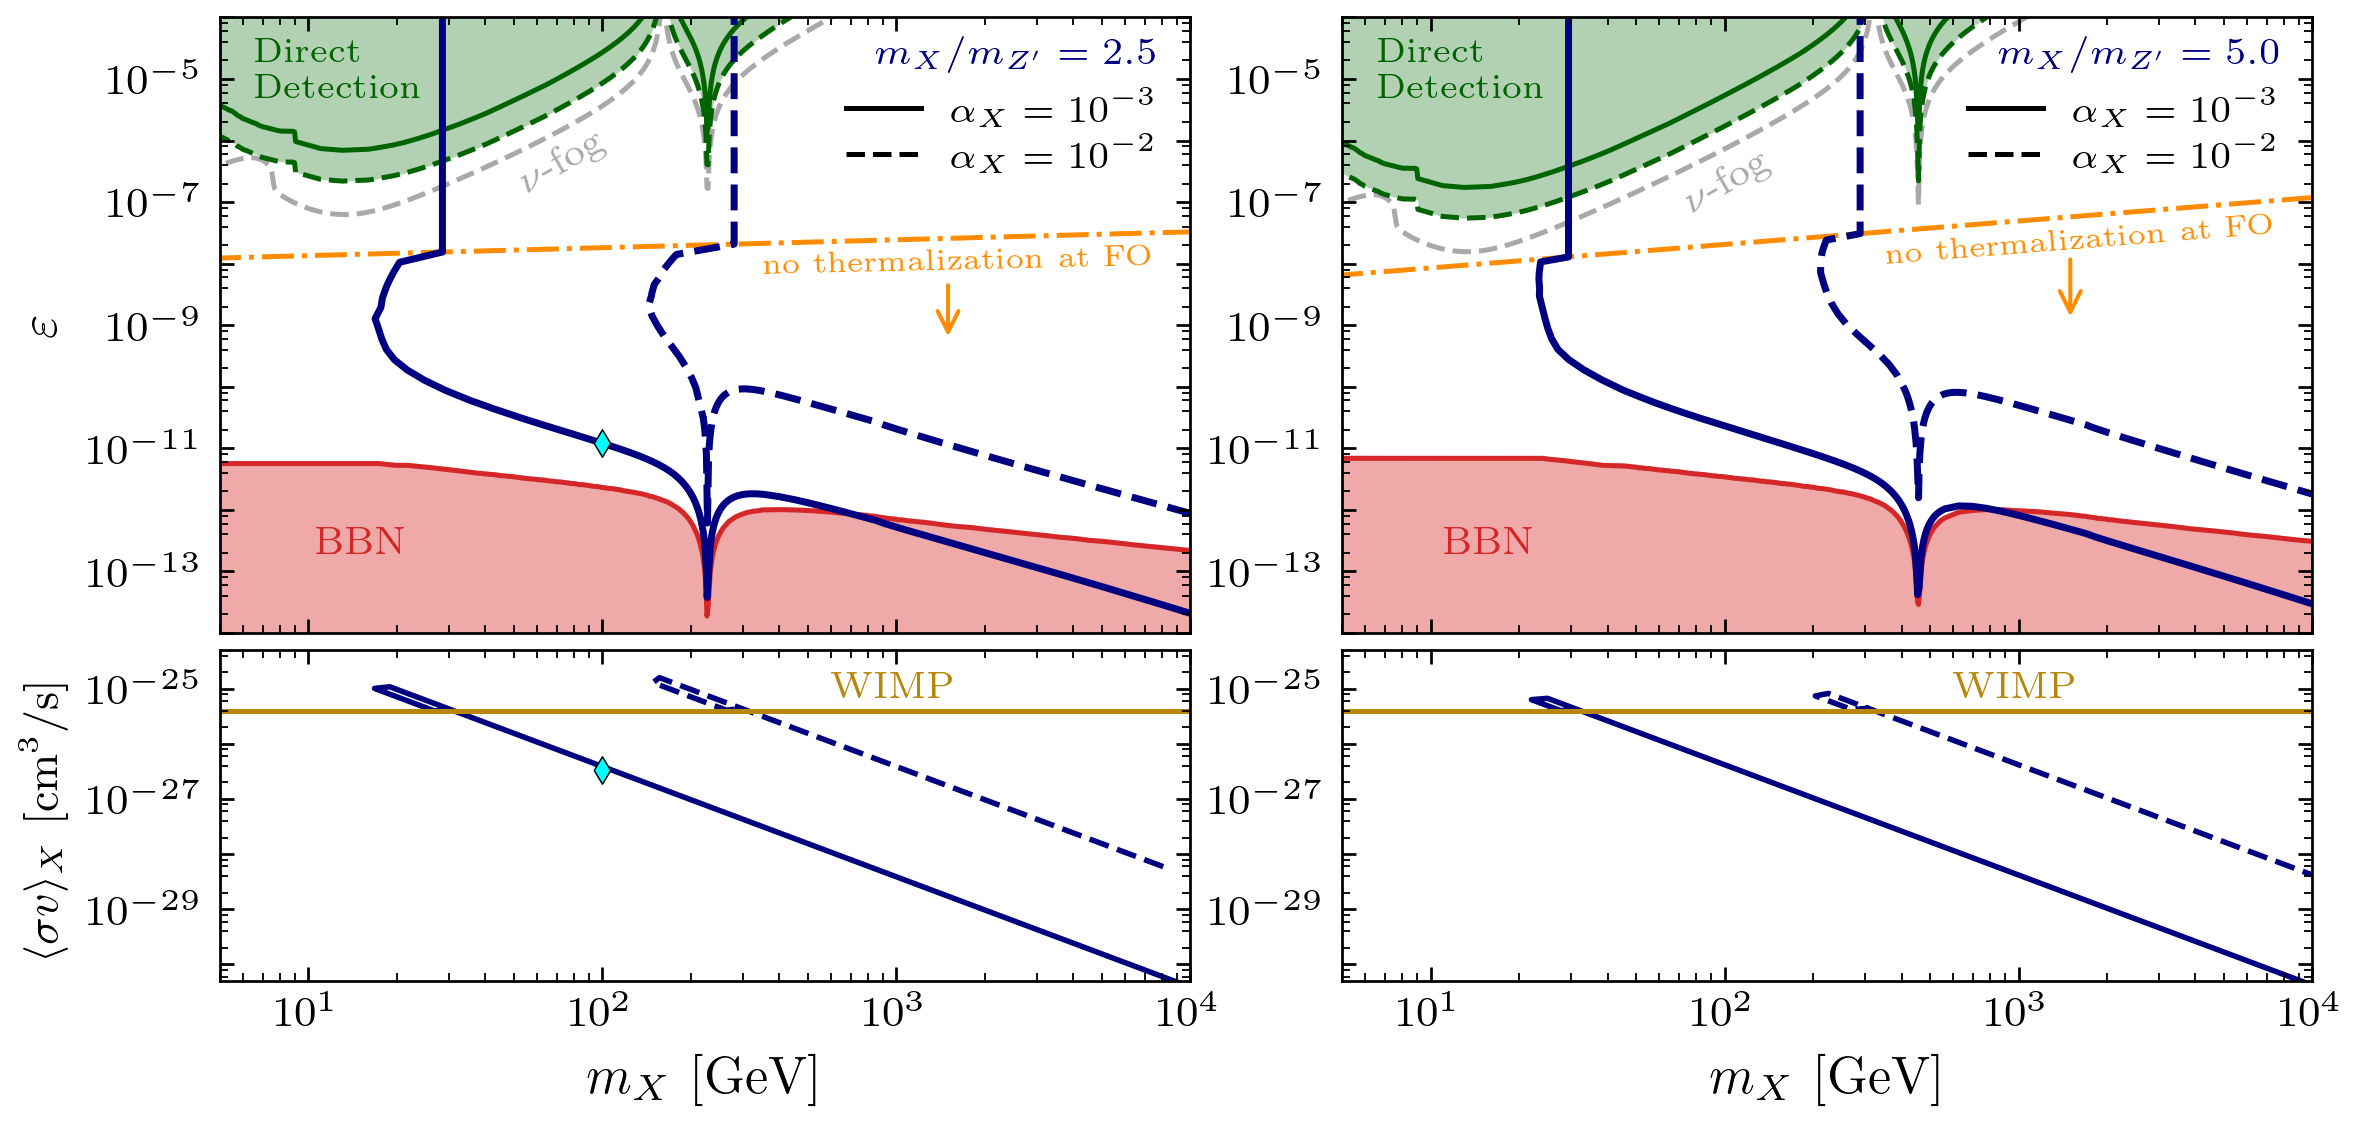

In [27]:
import matplotlib.pyplot as plt
import matplotlib.legend_handler as lh
from matplotlib.lines import Line2D
def color_shades(color, n, lightest_alpha=0.25):
    """Generate n shades from `color` to lighter, blended toward white.

    Parameters
    ----------
    color : str or RGB tuple
        Base color (e.g. "tab:blue").
    n : int
        Number of shades.
    lightest_alpha : float
        Fraction of base color in the lightest shade (0=white, 1=original).

    Returns
    -------
    list of hex color strings, from darkest to lightest.
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    fracs = np.linspace(1.0, lightest_alpha, n)
    return [mcolors.to_hex(rgb * f + white * (1 - f)) for f in fracs]


class MultiLineHandler(lh.HandlerBase):
    def __init__(self, colors, linestyle='-', linewidth=1):
        self.colors = colors
        self.linestyle = linestyle
        self.linewidth = linewidth
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        lines = []
        n = len(self.colors)
        for i, color in enumerate(self.colors):
            y = height - (i + 0.5) * height / n
            line = Line2D([xdescent, xdescent + width], [y, y],
                          color=color, linestyle=self.linestyle,
                          linewidth=self.linewidth, transform=trans)
            lines.append(line)
        return lines
def with_offset(x, y, offset=0.03, log=True):
    u, v = (np.log10(x), np.log10(y)) if log else (np.asarray(x, float), np.asarray(y, float))
    tu, tv = np.gradient(u), np.gradient(v)
    n = np.hypot(tu, tv); n[n == 0] = 1
    u = u - offset * tv / n
    v = v + offset * tu / n
    return (10**u, 10**v) if log else (u, v)

colors = ['tab:grey', 'navy', 'tab:red']
reds=color_shades('tab:red', 2,lightest_alpha=0.4)
#greys=color_shades('tab:grey', 2,lightest_alpha=0.4)
greys=color_shades('darkgreen', 2,lightest_alpha=0.3)
silvers=color_shades('darkgrey', 2,lightest_alpha=0.1)
# Dummy handles (just used as dict keys)
solid_handle = Line2D([], [])
dashed_handle = Line2D([], [])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.75))
gs1 = GridSpec(31,30,figure=fig1,hspace=1.2)
ax1 = fig1.add_subplot(gs1[:20,:14])
ax2 = fig1.add_subplot(gs1[:20,16:])
ax12 = fig1.add_subplot(gs1[20:,:14])
ax22 = fig1.add_subplot(gs1[20:,16:])
lss=['-','--', ':']
ZOs=[[-0.1,-.9],[-.1,-0.9],[-.1,-0.9]]
axs=[ax1,ax2]
axs1=[ax12, ax22]
therm_floor_r25=10**(interp1d(np.log10(therm_floors[::2][:,0]),np.log10(therm_floors[::2][:,1]), kind="linear", fill_value="extrapolate", bounds_error=False)(np.log10(dats[0]['mXs_bbn_dd'])))
therm_floor_r50=10**(interp1d(np.log10(therm_floors[1::2][:,0]),np.log10(therm_floors[1::2][:,1]), kind="linear", fill_value="extrapolate", bounds_error=False)(np.log10(dats[1]['mXs_bbn_dd'])))
ax1.plot(dats[0]['mXs_bbn_dd'],therm_floor_r25, lw=1, ls='-.', c='darkorange',zorder=-1)
ax2.plot(dats[1]['mXs_bbn_dd'],therm_floor_r50, lw=1, ls='-.', c='darkorange',zorder=-1)
for j in range(2):
    ax1.plot(dats[2*j]['mXs'],dats[2*j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    x1,y1=with_offset(dats[2*j]['mXs'][::5],dats[2*j]['svXs'][::5])
    ax12.plot(x1,y1,lw=1.1,c='navy',ls=lss[j],zorder=ZOs[j][0])
    #ax1.plot(np.NaN,np.NaN,lw=1.1,c='navy',ls=lss[j],label=r'$\alpha_X=\,$'+str(aXs_rs_tex[2*j][0]))
    #ax2.plot(np.NaN,np.NaN,lw=1.1,c='navy',ls=lss[j],label=r'$\alpha_X=\,$'+str(aXs_rs_tex[2*j][0]))
    if j==0:
        ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_bbn'],lw=1,color=reds[1],alpha=1,zorder=ZOs[j][1])
        ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
        ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_bbn'],lw=1,color=reds[1],alpha=1,zorder=ZOs[j][1])
        ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_bbn'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    if j==1:
        ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=1,color=silvers[0],ls=lss[j],zorder=ZOs[j][1])
        #ax1.fill_between(dats[2*j]['mXs_bbn_dd'],0, dats[2*j]['epsXs_nu'],lw=1,color=silvers[1],alpha=1,zorder=-2)
        ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=1,color=silvers[0],ls=lss[j],zorder=ZOs[j][1])
        #ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],0, dats[2*j+1]['epsXs_nu'],lw=1,color=silvers[1],alpha=1,zorder=-2)
    epsXs_DD = np.minimum(dats[2*j]['epsXs_LZ'], dats[2*j]['epsXs_XenT'])
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_LZ'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.fill_between(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax1.plot(dats[2*j]['mXs_bbn_dd'],epsXs_DD,lw=1,color=greys[0],ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_XenT'],lw=1,color='tab:red',ls=lss[j],zorder=ZOs[j][1])
    #ax1.plot(dats[2*j]['mXs_bbn_dd'],dats[2*j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    epsXs_DD = np.minimum(dats[2*j+1]['epsXs_LZ'], dats[2*j+1]['epsXs_XenT'])
    ax2.plot(dats[2*j+1]['mXs'],dats[2*j+1]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    x2,y2=with_offset(dats[2*j+1]['mXs'][::5],dats[2*j+1]['svXs'][::5])
    ax22.plot(x2,y2,lw=1.1,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_LZ'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.fill_between(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_XenT'],1,color=greys[1],alpha=1,zorder=ZOs[j][1],lw=0)
    ax2.plot(dats[2*j+1]['mXs_bbn_dd'],epsXs_DD,lw=1,color=greys[0],ls=lss[j],zorder=ZOs[j][1])
    #ax2.plot(dats[2*j+1]['mXs_bbn_dd'],dats[2*j+1]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel(r"$\varepsilon$")
#ax12.set_ylabel(r"$\langle \sigma v\rangle_{\rm s\mbox{-}wave}\,\,[{\rm cm^3}/{\rm s}]$", fontsize=9)
ax12.set_ylabel(r"$\langle \sigma v\rangle_{X}\,\,[{\rm cm^3}/{\rm s}]$", fontsize=9)
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(1e-14,1e-4)
    ax.set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['',r'$10^{-13}$','',r'$10^{-11}$','',r'$10^{-9}$','',r'$10^{-7}$','',r'$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xticklabels([])
    ax.legend(
    [solid_handle, dashed_handle],
    [r'$\alpha_X=10^{-3}$', r'$\alpha_X=10^{-2}$'],
    handler_map={
        solid_handle:  MultiLineHandler('k', linestyle='-'),
        dashed_handle: MultiLineHandler('k', linestyle='--'),
    },
    loc=(.63, 0.72),
             )
for ax in axs1:
    ax.set_yscale("log")
    ax.set_ylim(5e-31,5e-25)
    ax.set_yticks([1e-30,1e-29,1e-28,1e-27,1e-26, 1e-25])
    ax.set_yticklabels(['',r'$10^{-29}$','',r'$10^{-27}$','',r'$10^{-25}$'])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xscale("log")
    ax.set_xlim(5,1e4)
    ax.set_xlabel(r"$m_X$ [GeV]")
ax1.scatter(100,1.2410312592719208e-11,marker='d',s=15,color='cyan',linewidth=.3,edgecolor='k')
ax12.scatter(100,sigmav_XX_to_YY_swave(100,100/2.5,1e-3),marker='d',s=15,color='cyan',linewidth=.3,edgecolor='k')
ax1.text(3.5e2,7e-9,'no thermalization at FO',fontsize=6,color='darkorange', rotation=1.3)
ax2.text(3.5e2,1e-8,'no thermalization at FO',fontsize=6,color='darkorange', rotation=4.5)
# Draw arrow (shaft + head)
start = (1.5e3, 6.5e-9)
end = (1.5e3, 4.5e-10)
start2 = (1.5e3, 1.7e-8)
end2 = (1.5e3, 9.5e-10)
ax1.annotate('', xy=end, xytext=start,
            arrowprops=dict(arrowstyle='->', lw=.8, color='darkorange'))
ax2.annotate('', xy=end2, xytext=start2,
            arrowprops=dict(arrowstyle='->', lw=.8, color='darkorange'))
ax12.axhline(4e-26,lw=1,color='darkgoldenrod',ls="-",zorder=0.5)
ax22.axhline(4e-26,lw=1,color='darkgoldenrod',ls="-",zorder=0.5)
ax1.text(6.6,5e-6,"Direct\nDetection",fontsize=7,color=greys[0])
ax2.text(6.6,5e-6,"Direct\nDetection",fontsize=7,color=greys[0])
ax1.text(10.5,2e-13,"BBN",fontsize=8,color='tab:red')
ax2.text(11,2e-13,"BBN",fontsize=8,color='tab:red')
ax1.text(50,1.5e-7,r"$\nu$-fog",fontsize=8,color=silvers[0],rotation=30)
ax2.text(70,7e-8,r"$\nu$-fog",fontsize=8,color=silvers[0],rotation=30)
ax1.text(7.8e3,1.8e-5,r'$m_X/m_{Z^\prime}=2.5$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
ax2.text(7.8e3,1.8e-5,r'$m_X/m_{Z^\prime}=5.0$',color='navy', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
#ax12.text(6e2,8e-26,r' $\langle \sigma v \rangle_{\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
#ax22.text(6e2,8e-26,r' $\langle \sigma v \rangle_{\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax12.text(6e2,7e-26,r' ${\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax22.text(6e2,7e-26,r' ${\rm WIMP}$',color='darkgoldenrod', fontsize=mpl.rcParams['legend.fontsize'], ha='left')

plt.savefig("../letter_figs/vP_fig_v0.png")
plt.savefig("../letter_figs/vP_fig_v0.pdf")
plt.show()
plt.close()

## 2. Figure 2 of the Letter

In [2]:
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
# 1) Initialize hidden-sector model and its parameters
mXv=100
rv=2.5
mYv=mXv/rv
alphaXv=1e-3
model = VectorPortal(
        mX=mXv,       
        mY=mYv,       
        gX=2, gY=3,
        alphaX=alphaXv
    )
# 2) Solve boltzman equations
solver = BoltzmannSolver(cosmo, model)
sol0 = solver.solve_boltzmann_chempot_3phase(return_bg_ICs=True, verbose=True,n_points=1000,cannibal_switch_full=10,
                                             convergence_mode= "dlnxi_NR",convergence_threshold=1e-2)
# 3) find epsilon that gives correct DM relic abundance
epsXv= solver.find_epsilon_DMRelic(sol0['bg_ICs'],bg_kw={'correct_Y_decay': True})
print(epsXv)
# 4) Run background evolution for a particular epsilon
sol_bg = solver.solve_background(epsX=epsXv, bg_ICs=sol0['bg_ICs'],Nmax= 60.0,
                          stop_on_rhoY=False, verbose=False)

Boltzmann Solver -- QSSA Three-Phase
  mX = 1.00e+02 GeV, mY = 4.00e+01 GeV, r = 2.50
  Phase 1->1.5: Gamma_over_H_ann < 5e+09
  Phase 1.5->2: Gamma_over_H_can < 1e+01
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:   5%|█████▎                                                                                            | 7/129 [00:01<00:25,  4.78it/s]


  -> Phase 1.5 (QSSA) at x = 1.57 (Gamma_over_H_ann = 5.0e+09)


Evolving:  26%|█████████████████████████▌                                                                       | 34/129 [00:02<00:03, 28.52it/s]


  -> Phase 2 (full) at x = 20.09 (Gamma_over_H_can=1.0e+01, muX=0.00)


Evolving:  88%|████████████████████████████████████████████████████████████████████████████████████▊           | 114/129 [00:04<00:00, 23.88it/s]


  Converged (2, dlnxi_NR, event) at x = 341.5


------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 1.57
  x_switch (QSSA -> full): 20.09
  x_FO (muX > 0.05): 21.7
  Converged: True at x = 341.5
  YX_relic = 1.510566e-10
1.2410312592719208e-11


In [3]:
def xi_asymptotic(x, mX, xi0, x0):
    """
    Solve d ln xi / dx = (1 - 2*tildeg(T)) / x with xi(x0)=xi0,
    where T = mX / x.

    Vectorized in x. Assumes tildeg(T) behaves like your _interp wrapper:
    scalar -> scalar, array -> array.
    """
    x = np.asarray(x, dtype=float)

    if np.any(x <= 0) or x0 <= 0:
        raise ValueError("x and x0 must be positive.")
    if xi0 <= 0:
        raise ValueError("xi0 must be positive (since we evolve ln xi).")

    # Build integration grid that includes x0 and all requested x values
    x_flat = np.ravel(x)
    x_all = np.concatenate(([float(x0)], x_flat))

    order = np.argsort(x_all)
    xs = x_all[order]

    # Evaluate tildeg on the grid
    Ts = mX / xs
    gtil = cosmo.g_tilde(Ts)

    f = (1.0 - 2.0 * gtil) / xs  # integrand for d(ln xi)/dx
    #f = -1/xs
    # Cumulative trapezoid integral from xs[0] to xs[i]
    cum = np.empty_like(xs)
    cum[0] = 0.0
    dxs = np.diff(xs)
    cum[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * dxs)

    # Find where x0 landed in the sorted grid, and anchor there
    # (x0 is exactly included, so this should hit)
    idx0 = np.where(xs == float(x0))[0]
    if idx0.size == 0:
        # very defensive fallback for floating issues
        idx0 = np.argmin(np.abs(xs - float(x0)))
    else:
        idx0 = idx0[0]

    lnxi_grid = np.log(xi0) + (cum - cum[idx0])

    # Interpolate lnxi back to requested x values (fast)
    lnxi_flat = np.interp(x_flat, xs, lnxi_grid)
    xi_out = np.exp(lnxi_flat).reshape(x.shape)

    return xi_out.item() if xi_out.ndim == 0 else xi_out
xi_lim=xi_asymptotic(sol_bg['x'],mXv,sol0['xi'][-1],sol0['x'][-1])

No handles with labels found to put in legend.


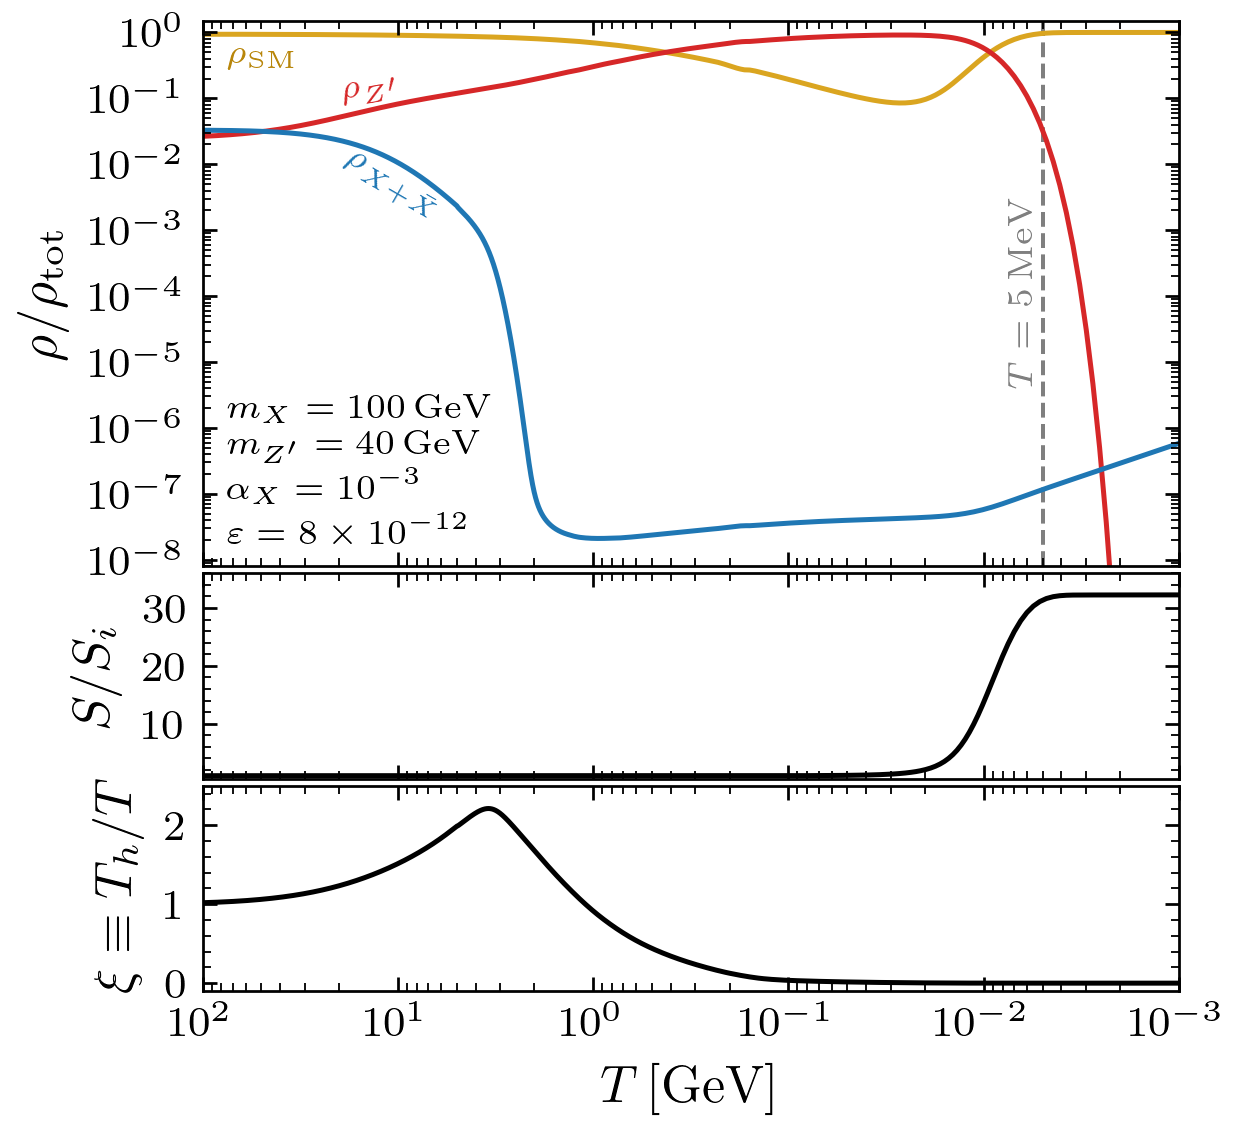

In [4]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(3.5, 3.5))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(23,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:18,:])
ax3 = fig1.add_subplot(gs1[18:,:])
#ax1.set_title(r'$m_{X}=100\,{\rm GeV},\,m_{Z^\prime}=50\,{\rm GeV},\, \alpha_X=10^{-3},\,\epsilon=8\times 10^{-12}$',fontsize=8)

ax1.text(75,2e-8,r'$m_{X}=100\,{\rm GeV}$'+'\n'+r'$m_{Z^\prime}=40\,{\rm GeV}$'+'\n'+r'$\alpha_X=10^{-3}$'+'\n'+r'$\varepsilon=8\times 10^{-12}$',
         rotation=0, fontdict={'fontsize':7,'family':'serif','color':'k'},
         ha='left')


ax1.plot(sol_bg['T'],sol_bg['rhoR']/sol_bg['rhoTot'],lw=1,c='goldenrod')
ax1.plot(sol_bg['T'],sol_bg['rhoY']/sol_bg['rhoTot'],lw=1,c='tab:red')
ax1.plot(sol_bg['T'],sol_bg['rhoX']/sol_bg['rhoTot'],lw=1,c='tab:blue')

ax1.set_ylim(.8e-8,1.5)
ax1.set_yscale("log")
ax1.set_xscale("log")
ax2.set_xscale("log")
ax3.set_xscale("log")
#ax1.axvline(mXv/sol0['x'][-1],ls='--',c='tab:gray',zorder=-1,lw=1)
#ax2.axvline(mXv/sol0['x'][-1],ls='--',c='tab:gray',zorder=-1,lw=1)

ax1.axvline(.5e-2,ls='--',c='tab:gray',zorder=-1,lw=.8)
ax1.text(1.5*.5e-2,5e-6,r'$T=5\,{\rm MeV}$',rotation=90, fontdict={'fontsize':7,'family':'serif','color':'tab:gray'})
ax3.set_xlabel(r"$T\,[\rm GeV]$")
ax1.set_ylabel(r"$\rho/\rho_{\rm tot}$")
ax3.set_ylabel(r"$\xi\equiv T_h/T$")
ax2.plot(sol_bg['T'],sol_bg['SoverSi'],lw=1,c='k')
ax3.plot(sol_bg['T'],sol_bg['xi'],lw=1,c='k')
#ax3.plot(mXv/sol_bg['x'],xi_lim,lw=1,c='tab:green',ls='--',label=r'$\frac{d\ln \xi}{d\ln x}= -1 -\frac{2}{3}\frac{d\ln{g}_S}{d\ln T}$')

ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax1.set_xlim(1e2,1e-3)
ax2.set_xlim(1e2,1e-3)
ax1.set_xticklabels([])
ax3.set_xlim(1e2,1e-3)
ax2.set_xticklabels([])
ax2.set_ylabel(r'$S/S_i$')
ax2.set_ylim(0.5,36)
ax2.set_yticks([10,20,30])
ax2.set_yticklabels([10,20,30])
ax3.set_ylim(-.1,2.5)
ax3.set_yticks([0,1,2])
ax1.set_yticks([1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
#ax2.set_yticks([1,1e1,1e2,1e3,1e4])
ax2.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax3.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax3.xaxis.set_minor_formatter(NullFormatter())
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.text(75,3.5e-1,r'$\rho_{\rm SM}$',rotation=0, fontdict={'fontsize':7,'family':'serif','color':'darkgoldenrod'})
ax1.text(2e1,1e-1,r'$\rho_{Z^\prime}$',rotation=10, fontdict={'fontsize':7,'family':'serif','color':'tab:red'})
ax1.text(2e1,2e-3,r'$\rho_{X+\bar{X}}$',rotation=-30, fontdict={'fontsize':7,'family':'serif','color':'tab:blue'})
ax3.legend()
plt.savefig("../letter_figs/fig2_v0.pdf")
plt.savefig("../letter_figs/fig2_v0.png")
plt.show()
plt.close()

## 3. Figure 1 of the Letter

In [34]:
from hidden_sector_DM.constants import SM_MYQ, alphaEM
from hidden_sector_DM.model import VectorPortal
from scipy.special import kn, zeta
ZETA3 = zeta(3)

def _common_bracket(s: float, mZp: float, mf: float) -> float:
    return s+6*mZp**2-7*mZp**4/s+2*(s-2*mZp**2+2*mZp**4/s)*np.log(s/mf**2*(1-mZp**2/s)**2)

def sigmav_gamma_f_to_Zp_f(f: str, s: float, mZp: float, epsX: float) -> float:
    """
    sigma * v for  gamma f -> Z' f.

    Parameters
    ----------
    f : str
        SM fermion key (e.g. "e", "mu", "u", "d", ...), looked up in SM_MYQ.
    s : float
        Mandelstam s (GeV^2).  Must satisfy s >= (mf + mZp)^2.
    mZp : float
        Z' mass (GeV).
    epsX : float
        Kinetic-mixing parameter.

    Returns
    -------
    sv : float
        Cross section times relative velocity (GeV^-2).
        Multiply by HBARC2 from constants.py to get cm^2.
    """
    mf, Qf = SM_MYQ[f][0], SM_MYQ[f][1]
    gfv, gfa = VectorPortal.gfv_gfa(f, mZp, epsX)
    prefac = alphaEM * Qf ** 2 * (gfv ** 2 + gfa ** 2) / (4.0 * s * s)
    return prefac * _common_bracket(s, mZp, mf)


def sigmav_Zp_f_to_gamma_f(f: str, s: float, mZp: float, epsX: float) -> float:
    """
    sigma * v for  Z' f -> gamma f  (inverse of the above).

    Same arguments and units as `sigmav_gamma_f_to_Zp_f`.
    """
    mf, Qf = SM_MYQ[f][0], SM_MYQ[f][1]
    gfv, gfa = VectorPortal.gfv_gfa(f, mZp, epsX)
    denom = (s - mZp * mZp) ** 2
    prefac = alphaEM * Qf ** 2 * (gfv ** 2 + gfa ** 2) / (6.0 * denom)
    return prefac * _common_bracket(s, mZp, mf)


def n_fermion_eq(f: str, T: float) -> float:
    """
    Relativistic equilibrium number density of SM fermion *f*
    (particle + antiparticle), ignoring the mass entirely.

    n_f + n_fbar = 2 * (3/4) * g_spin * Nc * zeta(3) T^3 / pi^2
                 = 3 Nc zeta(3) T^3 / pi^2
    """
    Nc = SM_MYQ[f][-1]
    return 3.0 * Nc * ZETA3 * T ** 3 / np.pi ** 2


def total_rate(T: float, mZp: float, epsX: float,
               process: str = "production") -> float:
    """
    Total interaction rate Gamma = sum_f n_f <sigma v>_f, evaluated at
    s = 16 T^2 (the typical cms^2 for relativistic 2->2 scattering).

    Parameters
    ----------
    T : float
        Temperature (GeV).
    mZp : float
        Z' mass (GeV).
    epsX : float
        Kinetic-mixing parameter.
    process : {"production", "destruction"}
        "production"  -> gamma f -> Z' f  (Z' production off fermions)
        "destruction" -> Z'    f -> gamma f

    Returns
    -------
    Gamma : float
        Rate in GeV.  Sums contributions from each SM fermion that is
        (i) electrically charged and (ii) kinematically accessible at
        s = 16 T^2, i.e. 16 T^2 > (mf + mZp)^2.
    """
    s = 16.0 * T ** 2
    sv_func = {
        "production":  sigmav_gamma_f_to_Zp_f,
        "destruction": sigmav_Zp_f_to_gamma_f,
    }[process]

    Gamma = 0.0
    for f, (mf, Qf, *_rest) in SM_MYQ.items():
        if Qf == 0.0 or mf == 0.0:
            continue
        if s <= (mf + mZp) ** 2:
            continue
        Gamma += n_fermion_eq(f, T) * sv_func(f, s, mZp, epsX)
    return Gamma

def gamma_decay_rest(mZp: float, epsX: float) -> float:
    """
    Rest-frame total width Gamma(Z' -> SM fbar f), GeV.

    Thin wrapper around VectorPortal.decay_width_to_all, kept here
    so the user only imports from this one module.
    """
    return VectorPortal.decay_width_to_all(mZp, epsX)


def gamma_decay_thermal(T: float, mZp: float, epsX: float) -> float:
    """
    Thermally averaged decay rate of Z' in a bath at temperature T.

    Accounts for time dilation of moving Z's:
        <Gamma> = Gamma_0 * <m/E> = Gamma_0 * K1(m/T) / K2(m/T),
    assuming Maxwell-Boltzmann statistics for the Z'.

    By detailed balance this is also the inverse-decay rate per Z' in
    equilibrium: f fbar -> Z' contributes the same per-Z' rate, so the
    same number is what you compare to H for (inverse-)decay
    thermalization.
    """
    G0 = gamma_decay_rest(mZp, epsX)
    x = mZp / T
    # K1/K2 -> 1 as x -> inf (non-relativistic) and -> x/2 as x -> 0.
    # scipy.special.kn handles both regimes; guard against huge x.
    if x > 500.0:
        return G0  # non-relativistic limit, no time dilation
    return G0 * kn(1, x) / kn(2, x)

def Gamma_heavy(T, M, alphaX, gY2=0.13, g_dof=20):
    """Rate per particle for SM-hidden scattering via heavy mediator.
    Interpolates between T^5/M^4 (low T) and T (high T)."""
    prefactor = 1.202 * g_dof / (16 * np.pi**2)  # zeta(3)*g_dof/(16 pi^2)
    return prefactor * alphaX * gY2 * T**5 / (T**2 + M**2)**2

In [35]:
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
Mv=1e12 #GeV
alphaXv=1e-3
epsv=1e-9
mXv=100 #GeV
mYv=40 #GeV
Ts=np.logspace(np.log10(1e3*Mv),np.log10(1e-2),1000)
Hs=cosmo.hubble(Ts)
GM=Gamma_heavy(Ts,Mv,alphaXv,g_dof=100)
G_decay=np.array([gamma_decay_thermal(T,mYv,epsv) for T in Ts])
G_scat=np.array([total_rate(T, mYv, epsv) for T in Ts])

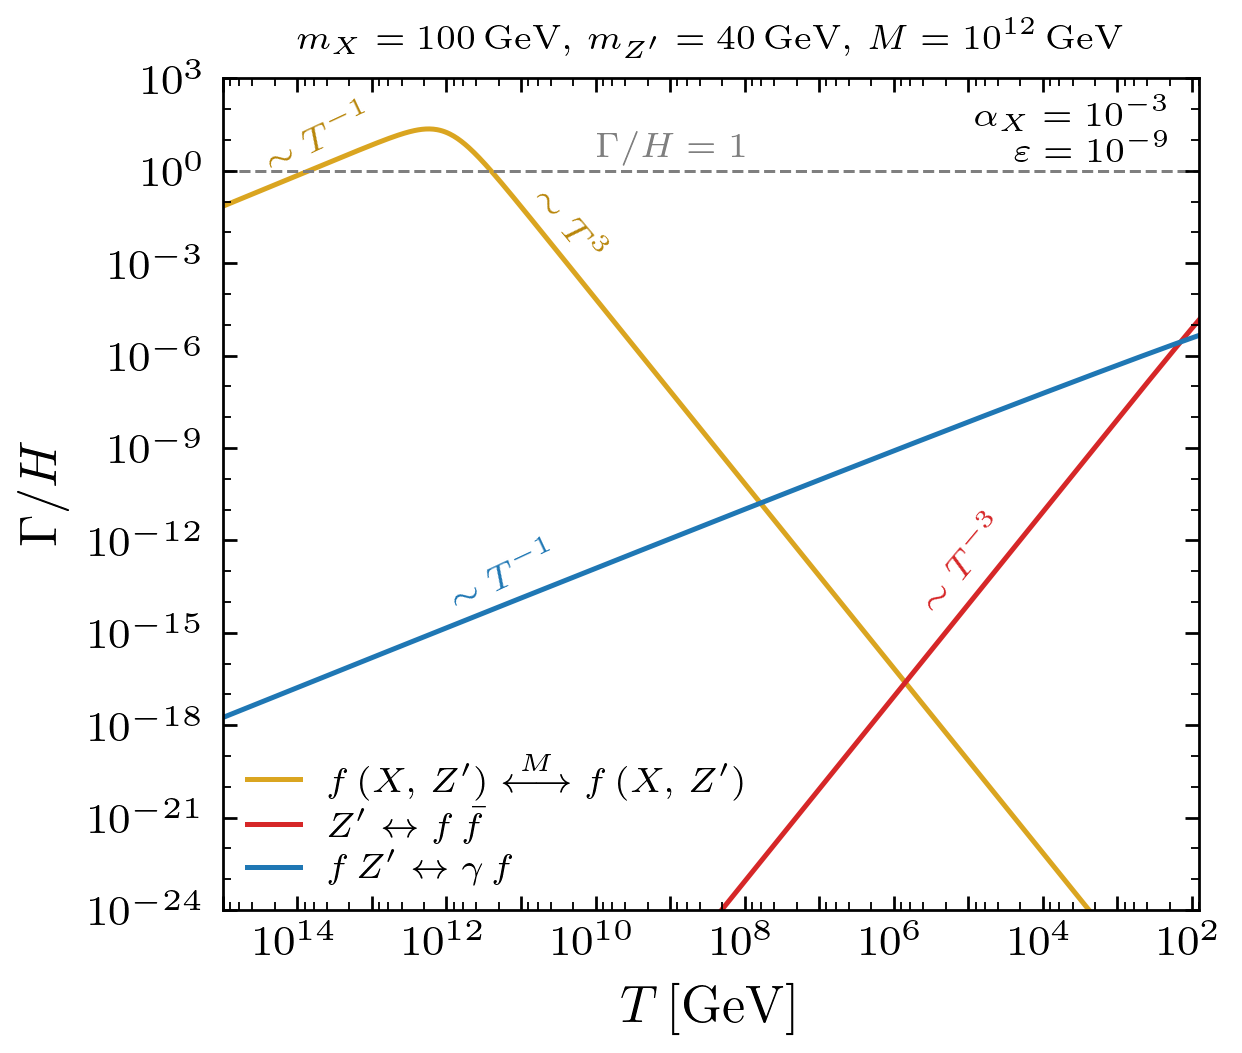

In [38]:
fig1=plt.figure(figsize=(3.5, 3))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(23,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:])

ax1.plot(Ts,GM/Hs,lw=1,c='goldenrod',label=r'$f \, (X,\,Z^\prime) \stackrel{M}{\longleftrightarrow} f \, (X,\,Z^\prime)$')
ax1.plot(Ts,G_decay/Hs,lw=1,c='tab:red',label=r'$ Z^\prime \leftrightarrow f\, \bar f$')
ax1.plot(Ts,G_scat/Hs,lw=1,c='tab:blue',label=r'$f \, Z^\prime \leftrightarrow \gamma \, f$')
ax1.axhline(1,ls='--',lw=.6,c='tab:grey')
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.legend(
    loc=3,
    fontsize=7,
    framealpha=0.9,      # 0.0 = fully transparent, 1.0 = fully opaque
    handlelength=1.5,    # default is ~2.0; smaller = shorter lines in legend
)
ax1.text(1e10,3,'$\Gamma/H=1$',rotation=0, fontdict={'fontsize':7,'family':'serif','color':'tab:grey'})
ax1.text(3e14,1,'$\sim T^{-1}$',rotation=25, fontdict={'fontsize':7,'family':'serif','color':'darkgoldenrod'})
ax1.text(8e10,1e-3,'$\sim T^3$',rotation=-50, fontdict={'fontsize':7,'family':'serif','color':'darkgoldenrod'})
ax1.text(5e5,5e-15,'$\sim T^{-3}$',rotation=50, fontdict={'fontsize':7,'family':'serif','color':'tab:red'})
ax1.text(1e12,6e-15,'$\sim T^{-1}$',rotation=25, fontdict={'fontsize':7,'family':'serif','color':'tab:blue'})
ax1.set_title(r'$m_{X}=100\,{\rm GeV},\,m_{Z^\prime}=40\,{\rm GeV},\,M=10^{12}\,{\rm GeV}$',fontsize=7)
ax1.text(2e2,2,r'$\alpha_X=10^{-3}$'+'\n'+r'$\varepsilon=10^{-9}$',rotation=0, fontdict={'fontsize':7,'family':'serif','color':'k'},
         ha='right')
ax1.set_yticks([1e-24,1e-21,1e-18,1e-15,1e-12,1e-9,1e-6,1e-3,1,1e3])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[1], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
ax1.set_xticks([1e15,1e14,1e13,1e12,1e11,1e10,1e9,1e8,1e7,1e6,1e5,1e4,1e3,1e2])
ax1.set_xticklabels(['',r'$10^{14}$','',r'$10^{12}$','',r'$10^{10}$','',r'$10^{8}$','',r'$10^{6}$','',r'$10^{4}$','',r'$10^{2}$'])
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2,0.4,0.6,0.8], numticks=2000))
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.set_xlabel(r"$T\,[\rm{GeV}]$")
ax1.set_ylabel(r"$\Gamma/H$")
ax1.set_ylim(1e-24,1e3)
ax1.set_xlim(8e1,1e3*Mv)
ax1.invert_xaxis()
plt.savefig("../letter_figs/fig1_v0.pdf")
plt.savefig("../letter_figs/fig1_v0.png")
plt.show()

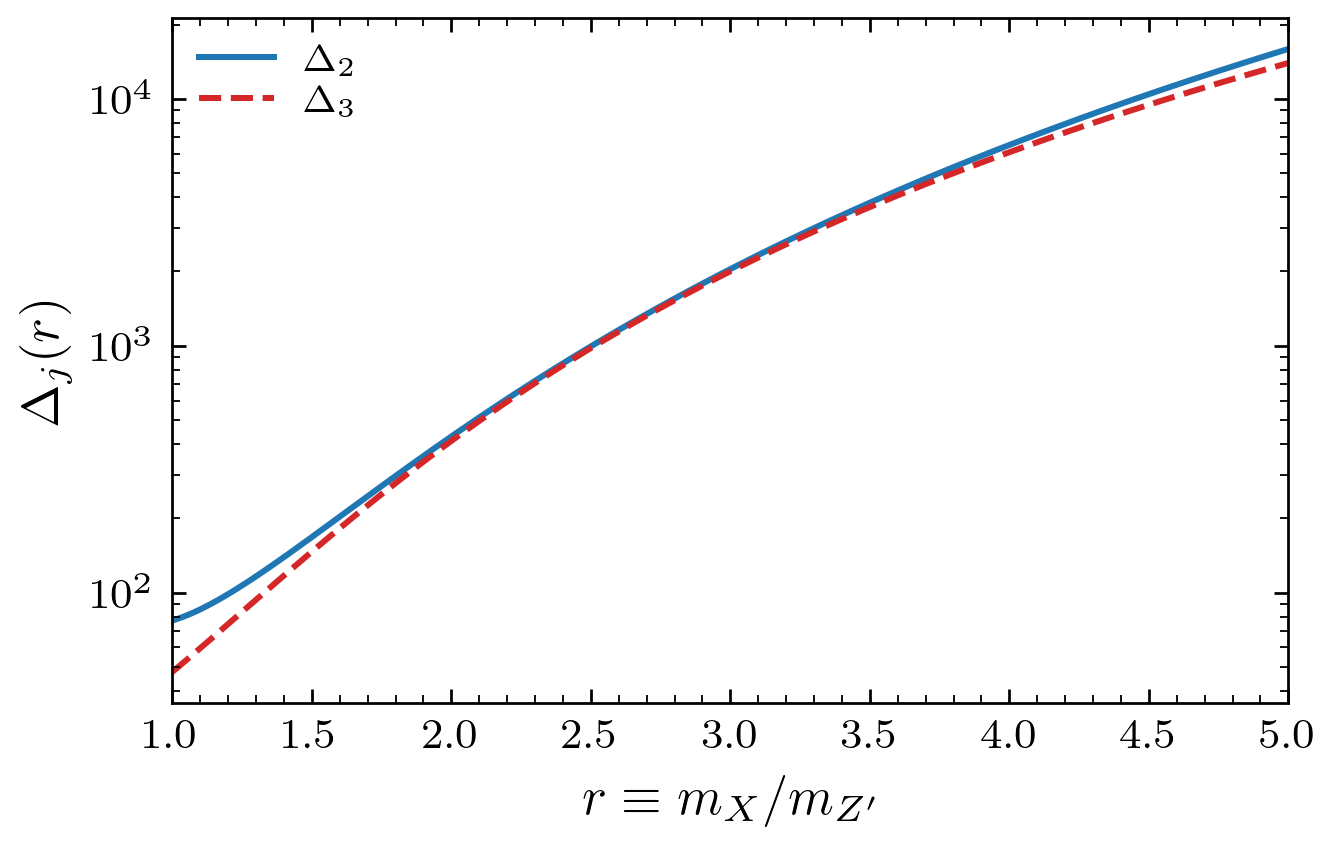

In [13]:
def N2(r):
    return 256*r**6 - 384*r**5 + 536*r**4 - 96*r**3 + 38*r**2 + 72*r + 31
 
def N3(r):
    # As given: no r^7 or r^1 terms
    return (320*r**10 + 2272*r**9 + 6732*r**8 + 5596*r**6
            + 12214*r**5 + 9444*r**4 + 4670*r**3 + 1156*r**2 + 195)
 
def Delta2(r):
    num = np.pi**2 * r**3 * (1 + 4*r)**1.5 * N2(r)
    den = 6 * (1 + 2*r)**3 * (2*r**2 + r - 1)**2
    return num / den
 
def Delta3(r):
    num = 4 * np.pi**2 * r**5 * np.sqrt((4.0/3.0)*r*(r+2) + 1) * N3(r)
    den = (r+2)**3 * (2*r+1)**4 * (2*r**2*(r+2) + r - 1)**2
    return num / den
 
r = np.linspace(1, 5, 500)
d2 = Delta2(r)
d3 = Delta3(r)
 
fig1=plt.figure(figsize=(4, 4/1.61803398875))
gs1 = GridSpec(23,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:])
ax1.plot(r, d2, color='C0', lw=1.2, label=r'$\Delta_2$')
ax1.plot(r, d3, color='C3', lw=1.2, label=r'$\Delta_3$',ls='--')
ax1.set_yscale("log")
ax1.set_xlim(1,5)
ax1.set_xlabel(r'$r\equiv m_X/m_{Z^\prime}$')
ax1.set_ylabel(r'$\Delta_j(r)$')
ax1.legend()
plt.show()
plt.close()
 